In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import torch
import numpy as np
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import cv2
import matplotlib.pyplot as plt
from dataset import HandsDataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

hand_keypoints_train = datasets.CocoDetection(root='../hand_keypoints_dataset/hand_keypoint_dataset_26k/hand_keypoint_dataset_26k/images/train', 
                                    annFile='../hand_keypoints_dataset/hand_keypoint_dataset_26k/hand_keypoint_dataset_26k/coco_annotation/train/_annotations.coco.json', 
                                    transform=transform)

train_data_loader = DataLoader(hand_keypoints_train, batch_size=4, shuffle=True)

loading annotations into memory...
Done (t=0.29s)
creating index...
index created!


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

hand_keypoints_train = datasets.CocoDetection(root='../hand_keypoints_dataset/hand_keypoint_dataset_26k/hand_keypoint_dataset_26k/images/val', 
                                    annFile='../hand_keypoints_dataset/hand_keypoint_dataset_26k/hand_keypoint_dataset_26k/coco_annotation/val/_annotations.coco.json', 
                                    transform=transform)

val_data_loader = DataLoader(hand_keypoints_train, batch_size=4, shuffle=True)

loading annotations into memory...
Done (t=0.20s)
creating index...
index created!


In [4]:
for sample in train_data_loader:
    first = sample
    break

print(sample[0].shape)
print(type(sample[1]))

torch.Size([4, 3, 224, 224])
<class 'list'>


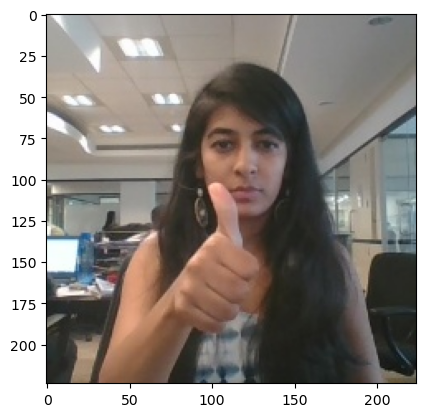

In [5]:
plt.imshow(sample[0][0].permute(1, 2, 0))

dict_keys(['id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd', 'keypoints'])
torch.Size([4])
torch.Size([4])
torch.Size([4])
4
torch.Size([4])
0
torch.Size([4])
63
[tensor([85, 88, 88,  0]), tensor([  7, 187, 210,   0]), tensor([2, 2, 2, 0]), tensor([118, 106, 116,   0]), tensor([ 25, 176, 203,   0]), tensor([2, 2, 2, 0]), tensor([139, 113, 139, 156]), tensor([ 56, 157, 183,  27]), tensor([2, 2, 2, 2]), tensor([155, 117, 158, 156]), tensor([ 82, 140, 165,  63]), tensor([2, 2, 2, 2]), tensor([171, 124, 180, 158]), tensor([103, 129, 154,  93]), tensor([2, 2, 2, 2]), tensor([106, 101, 118, 131]), tensor([104, 134, 134,  64]), tensor([2, 2, 2, 2]), tensor([111,  99, 123, 133]), tensor([138, 112, 102, 113]), tensor([2, 2, 2, 2]), tensor([112,  97, 124, 132]), tensor([159, 100,  82, 141]), tensor([2, 2, 2, 2]), tensor([113,  95, 126, 130]), tensor([177,  89,  64, 162]), tensor([2, 2, 2, 2]), tensor([ 84,  90, 102, 106]), tensor([104, 134, 131,  65]), tensor([2, 2, 2, 

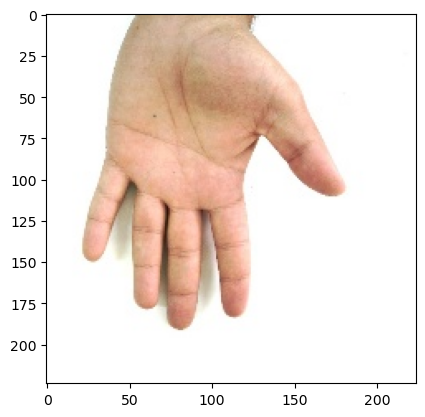

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for train_inputs, train_labels in iter(train_data_loader):
    train_samples = train_inputs.to(device)

    for entry in train_labels:
        print(entry.keys())
        for key in entry.keys():
            try:
                print(entry[key].size())
            except:
                print(len(entry[key]))
    break
    # loss = loss_fcn(train_outputs, train_samples)
plt.imshow(train_inputs[0].permute(1, 2, 0))
print(entry['keypoints'])

test
loading annotations into memory...
Done (t=0.32s)
creating index...
index created!
torch.Size([4, 21, 3])


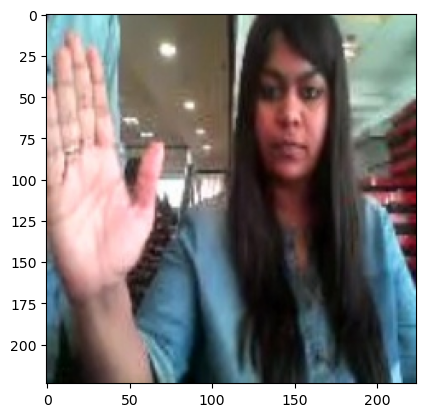

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

hand_keypoints_train = HandsDataset(root='../hand_keypoints_dataset/hand_keypoint_dataset_26k/hand_keypoint_dataset_26k/images/train', 
                                    annFile='../hand_keypoints_dataset/hand_keypoint_dataset_26k/hand_keypoint_dataset_26k/coco_annotation/train/_annotations.coco.json', 
                                    transform=transform)

train_data_loader = DataLoader(hand_keypoints_train, batch_size=4, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for train_inputs, train_labels in iter(train_data_loader):
    train_samples = train_inputs.to(device)

    print(train_labels.size())
    break
plt.imshow(train_inputs[0].permute(1, 2, 0))

In [1]:
from dataset import HandsDataset
import os

print(os.cpu_count())

6
